In [2]:
# Standard libraries
import os
from typing import List, Tuple

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, mutual_info_regression, f_classif, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Other utilities
from scipy.stats import randint, uniform
import joblib

In [3]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [4]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
cleandf = pd.read_parquet(os.path.join(path, "03_CLEAN_COMPLETE_DF.parquet"))
cleandf

,TotalAbundance_SamplingOperation,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,Uncommon_Taxons,IBD,IBD_EQR,IBD_EQR_Status
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S02000008_20170703,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.407407,NaN,NaN,88.888889,NaN,NaN,NaN,2.469136,NaN,NaN,NaN,NaN,4.938272,NaN,NaN,187.654321,NaN,2.469136,NaN,44.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.938272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.469136,2.469136,NaN,NaN,NaN,NaN,NaN,NaN,32.098765,4.938272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261.728395,NaN,NaN,283.950617,NaN,NaN,NaN,NaN,19.753086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.469136,NaN,NaN,NaN,7.407407,NaN,NaN,NaN,NaN,NaN,7.407407,NaN,14.814815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.283951,1039055.0,6721258.0,Rhin-Meuse,68,18,ALSACE,73,0.0,TP,Good,Good,Good,Moderate,Moderate,Moderate,Good,Good,Moderate,High,High,High,None,None,None,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good,0.000000,9.6,0.502924,Poor
S02000008_20200708,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,10.000000,NaN,5.000000,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,NaN,NaN,7.5,137.500000,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,195.000000,10.0,NaN,432.500000,NaN,NaN,NaN,NaN,NaN,5.0,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,15.000000,12.5,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,22.500000,1039055.0,6721258.0,Rhin-Meuse,68,18,ALSACE,73,0.0,TP,Good,Good,Good,Moderate,Moderate,Moderate,Moderate,Moderate,Moderate,Good,Good,High,Moderate,Moderate,Moderate,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good,5.000000,8.0,0.409357,Poor
S02000010_20070906,400,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,

In [12]:
# lets drop the rows that have NaN in IBD
cleandf = cleandf[cleandf['IBD'].notna()]

In [13]:
cleandf

,TotalAbundance_SamplingOperation,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,Altitude,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,Uncommon_Taxons,IBD,IBD_EQR,IBD_EQR_Status
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S02000008_20170703,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.407407,NaN,NaN,88.888889,NaN,NaN,NaN,2.469136,NaN,NaN,NaN,NaN,4.938272,NaN,NaN,187.654321,NaN,2.469136,NaN,44.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.938272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.469136,2.469136,NaN,NaN,NaN,NaN,NaN,NaN,32.098765,4.938272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261.728395,NaN,NaN,283.950617,NaN,NaN,NaN,NaN,19.753086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.469136,NaN,NaN,NaN,7.407407,NaN,NaN,NaN,NaN,NaN,7.407407,NaN,14.814815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.283951,1039055.0,6721258.0,Rhin-Meuse,68,18,ALSACE,73,0.0,TP,Good,Good,Good,Moderate,Moderate,Moderate,Good,Good,Moderate,High,High,High,None,None,None,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good,0.000000,9.6,0.502924,Poor
S02000008_20200708,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,10.000000,NaN,5.00000,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,NaN,NaN,7.5,137.500000,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,195.000000,10.000000,NaN,432.500000,NaN,NaN,NaN,NaN,NaN,5.0,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,15.000000,12.5,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,22.500000,1039055.0,6721258.0,Rhin-Meuse,68,18,ALSACE,73,0.0,TP,Good,Good,Good,Moderate,Moderate,Moderate,Moderate,Moderate,Moderate,Good,Good,High,Moderate,Moderate,Moderate,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good,5.000000,8.0,0.409357,Poor
S02000010_20070906,400,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN

In [6]:
X = cleandf.drop(columns=['IBD','IBD_EQR','IBD_EQR_Status'])
y = cleandf['IBD']

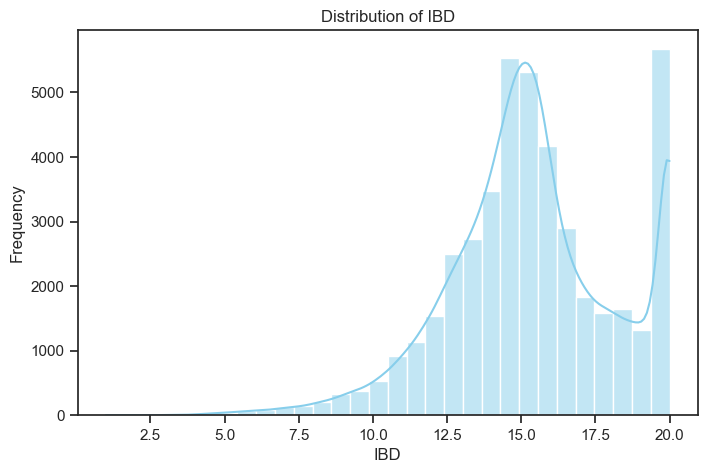

In [6]:
# plot y
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=30, kde=True, color='skyblue')
plt.title('Distribution of IBD')
plt.xlabel('IBD')
plt.ylabel('Frequency')
plt.show()

# Random Forest Classifier for IBD

In [11]:
# 1) Split
X = cleandf.drop(columns=['IBD','IBD_EQR','IBD_EQR_Status'])
y = cleandf['IBD']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 2) Identify column types
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.columns.difference(num_cols)

# 3) Preprocess
# this preprocessor can handle missing values   
pre = ColumnTransformer([
    # numerical features
    ('num', Pipeline([
        # imputation and scaling
        ('imp', SimpleImputer(strategy='median')),
        # scaling (RF doesn't need it, but other models might)
        # ('scaler', StandardScaler(with_mean=False))  # stays sparse with OHE
    ]), num_cols),
    # categorical features
    ('cat', Pipeline([
        # imputation as None being another category
        ('imp', SimpleImputer(strategy='constant', fill_value='None')),
        # one-hot encoding, ignoring unknown categories during inference
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)

])

# 4) Model
clf = Pipeline([
    ('pre', pre),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))  # for regression
])  

In [9]:
clf.fit(X_tr, y_tr)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['TotalAbundance_SamplingOperation', 'Achat02', 'Achca02', 'Achco02',
       'Achde03', 'Achdr01', 'Acheu01', 'Achge01', 'Achla02', 'Achla04',
       ...
       'Surla01', 'Synde01', 'Synul01', 'Vibtr01', 'Longitude_Lambert93',
       'Latitude_Lambert93', 'HERlvl1Cod...
       'OrganicMicropollutants_Status1Y', 'OrganicMicropollutants_Status90D',
       'PAH_Status180D', 'PAH_Status1Y', 'PAH_Status90D',
       'Phosphorouscompounds_Status180D', 'Phosphorouscompounds_Status1Y',
       'Phosphorouscompounds_Status90D', 'Streamsize',
       'SuspendedMatter_Status180D', 'SuspendedMatter_Status1Y',
       'SuspendedMatter_Status90D', 'Watershed'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [10]:
print("R2 train:", clf.score(X_tr, y_tr))
print("R2 valid:", clf.score(X_te, y_te))

R2 train: 0.9871267855490886
R2 valid: 0.9148400382609909


# Correr esto en la uni

In [ ]:
# # 2) Column types
# num_cols = X_tr.select_dtypes(include=['number']).columns
# cat_cols = X_tr.columns.difference(num_cols)

In [ ]:
# # 3) Preprocess (force dense OHE for RF compatibility across sklearn versions)
# try:
#     ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# except TypeError:  # older sklearn
#     ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
#     print("Using sparse=False in OneHotEncoder, which may be inefficient for large datasets. Consider updating scikit-learn.")

In [ ]:
# pre = ColumnTransformer(
#     transformers=[
#         ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
#         ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='None')),
#                           ('ohe', ohe)]), cat_cols),
#     ],
#     remainder='drop',
#     verbose_feature_names_out=False
# )

In [ ]:
# # 4) RF model + pipeline
# rf = RandomForestRegressor(
#     n_estimators=200,       # number of trees
#     bootstrap=True,         # required for oob_score_
#     oob_score=True,
#     n_jobs=-1,
#     random_state=42,
#     min_samples_leaf=10,     # to reduce overfitting
#     min_samples_split=50,    # to reduce overfitting
# )

# pipe = Pipeline([
#     ('pre', pre),
#     ('model', rf)
# ])

In [ ]:
# # 5) Hyperparameter search (RF only)
# param_dist = {
#     'model__n_estimators': randint(400, 1201),
#     'model__max_depth': [None, 8, 12, 20, 30],
#     'model__max_features': ['sqrt', 'log2', 0.3, 0.5, 1.0],
#     'model__min_samples_split': randint(2, 21),
#     'model__min_samples_leaf': randint(1, 21),
#     'model__max_samples': [None, 0.6, 0.8, 0.9],  # subsampling decorrelates trees
# }

# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# search = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_dist,
#     n_iter=60,
#     scoring='neg_root_mean_squared_error',
#     cv=cv,
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
#     refit=True
# )

# search.fit(X_tr, y_tr)
# best_model = search.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits


In [ ]:
# # 6) Evaluation
# y_hat = best_model.predict(X_te)
# rmse = mean_squared_error(y_te, y_hat, squared=False)
# r2 = r2_score(y_te, y_hat)
# oob = best_model.named_steps['model'].oob_score_

# print("Best params:", search.best_params_)
# print(f"Test RMSE: {rmse:.4f}")
# print(f"Test R^2 : {r2:.4f}")
# print(f"OOB R^2  : {oob:.4f}")

In [ ]:
# # 7) Top feature importances (after OHE)
# feat_names = best_model.named_steps['pre'].get_feature_names_out()
# imp = pd.Series(best_model.named_steps['model'].feature_importances_, index=feat_names)
# print("\nTop 25 features:\n", imp.sort_values(ascending=False).head(25))


# si quiero a mi compu

In [19]:
yhat = clf.predict(X_te)

In [20]:
# Calculate regression metrics
mse = mean_squared_error(y_te, yhat)
mae = mean_absolute_error(y_te, yhat)
r2 = r2_score(y_te, yhat)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")

Mean Squared Error: 0.6825687874343249
Mean Absolute Error: 0.5225425256030023
R2 Score: 0.9147090099387029


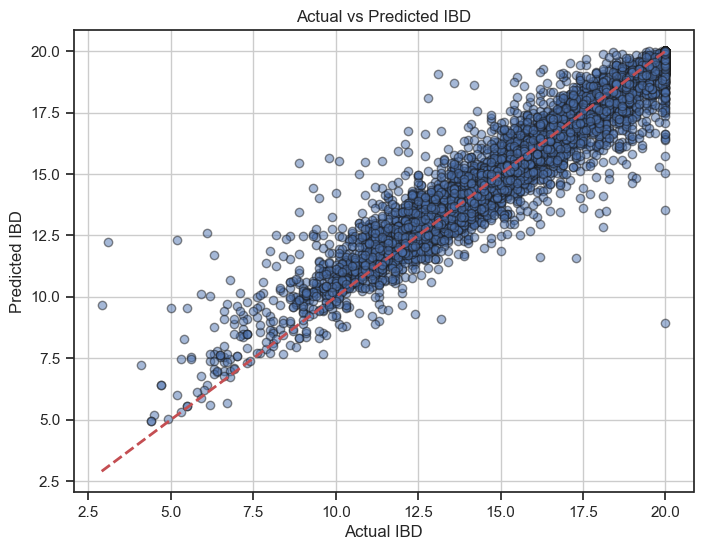

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_te, yhat, alpha=0.5, edgecolor='k')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
plt.xlabel('Actual IBD')
plt.ylabel('Predicted IBD')
plt.title('Actual vs Predicted IBD')
plt.grid(True)
plt.show()

In [ ]:
# # save the model

# joblib.dump(clf, 'first_random_forest.joblib', compress=("zlib", 3))

# # to read it back
# # clf = joblib.load('first_random_forest.joblib') 


['first_random_forest.joblib']

In [ ]:
# can i know if S04207000_20130812 is in the training set?
code = "S04207000_20130812"
code in X.index

False